# Flow vs Jump vs Jump+Flow — 2D Checkerboard Comparison

This notebook trains and compares three generative models on the 2D Single Gaussian dataset:

| Model | Transport | Description |
|-------|-----------|-------------|
| **Flow** | ODE | Standard CondOT flow matching (velocity field) |
| **Jump-only** | CTMC | Pure jump process on discretized R² (eq. 13) |
| **Jump+Flow** | ODE+CTMC | Markov superposition of flow and jump (Algorithm 2) |

All models share the same CondOT probability path and are trained with the same MLP architecture.

Reference: *Generator Matching* (Holderrieth et al., ICLR 2025)

## Imports

In [1]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='torch')

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import ODESolver
from flow_matching.utils import ModelWrapper

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Using: {device}')
torch.manual_seed(42)

Using: cuda:0


## Dataset — 2D Checkerboard

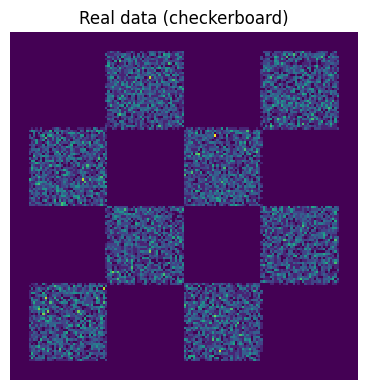

In [3]:
def inf_train_gen(batch_size: int = 200, device: str = 'cpu') -> Tensor:
    """2D checkerboard, identical to examples/2d_flow_matching.ipynb."""
    x1 = torch.rand(batch_size, device=device) * 4 - 2
    x2_ = torch.rand(batch_size, device=device) - torch.randint(high=2, size=(batch_size,), device=device) * 2
    x2 = x2_ + (torch.floor(x1) % 2)
    data = torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45
    return data.float()

# Quick sanity check plot
real = inf_train_gen(batch_size=20000, device='cpu').numpy()
fig, ax = plt.subplots(figsize=(4, 4))
ax.hist2d(real[:, 0], real[:, 1], bins=200, range=((-5, 5), (-5, 5)))
ax.set_title('Real data (checkerboard)')
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()


## Model Architecture

All models share the same MLP backbone. Outputs differ:
- **Flow**: velocity `[B, 2]`
- **Jump-only**: `(jump_logits [B, 2, NUM_BINS], log_lambda [B, 2])`
- **Jump+Flow**: `(velocity [B, 2], jump_logits [B, 2, NUM_BINS], log_lambda [B, 2])`

Jump distribution `J_θ` is parameterized as a **categorical over NUM_BINS bins** covering `[-DATA_RANGE, DATA_RANGE]`.
At sampling time, the bin center is shifted by uniform dequantization noise to produce a continuous sample.

In [4]:
class Swish(nn.Module):
    def forward(self, x: Tensor) -> Tensor:
        return x * torch.sigmoid(x)


class FlowMLP(nn.Module):
    """Standard flow matching velocity model."""
    def __init__(self, hidden_dim: int = 512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim), Swish(),
            nn.Linear(hidden_dim, hidden_dim), Swish(),
            nn.Linear(hidden_dim, hidden_dim), Swish(),
            nn.Linear(hidden_dim, hidden_dim), Swish(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        t_in = t.reshape(-1, 1).expand(x.shape[0], 1)
        return self.net(torch.cat([x, t_in], dim=1))


class JumpMLP(nn.Module):
    """Binned jump model: J_theta = Categorical over NUM_BINS bins per dimension.

    with_flow=False -> (jump_logits [B,2,NUM_BINS], log_lambda [B,2])
    with_flow=True  -> (velocity [B,2], jump_logits [B,2,NUM_BINS], log_lambda [B,2])
    """
    def __init__(self, hidden_dim: int = 512, num_bins: int = 64,
                 with_flow: bool = False):
        super().__init__()
        self.num_bins  = num_bins
        self.with_flow = with_flow
        self.backbone = nn.Sequential(
            nn.Linear(3, hidden_dim), Swish(),
            nn.Linear(hidden_dim, hidden_dim), Swish(),
            nn.Linear(hidden_dim, hidden_dim), Swish(),
            nn.Linear(hidden_dim, hidden_dim), Swish(),
        )
        # output 2*num_bins logits (2 spatial dims × num_bins bins)
        self.jump_logits_head  = nn.Linear(hidden_dim, 2 * num_bins)
        self.log_lambda_head   = nn.Linear(hidden_dim, 2)
        if with_flow:
            self.velocity_head = nn.Linear(hidden_dim, 2)

    def forward(self, x: Tensor, t: Tensor):
        B = x.shape[0]
        t_in   = t.reshape(-1, 1).expand(B, 1)
        feat   = self.backbone(torch.cat([x, t_in], dim=1))
        logits = self.jump_logits_head(feat).view(B, 2, self.num_bins)  # [B,2,nb]
        log_lambda = self.log_lambda_head(feat)                          # [B,2]
        if self.with_flow:
            return self.velocity_head(feat), logits, log_lambda
        return logits, log_lambda

## Jump Model: Bins, Conditional Kernel, and Loss

We discretize each spatial dimension into `NUM_BINS` bins covering `[-DATA_RANGE, DATA_RANGE]`.

**Conditional jump kernel** (eq. 13, per dimension independently):

$$k_t(x) = x^2 - (t+1)\,x\,z - (1-t)^2 + t\,z^2$$

$$\lambda_z(x_t) = \frac{[k_t(x_t)]_+}{(1-t)^3}, \qquad J_z(b_j) \propto [-k_t(b_j)]_+ \cdot \mathcal{N}(b_j;\, t\,z,\,(1-t)^2)$$

**CGM loss** (paper Table 1, exact Bregman divergence for jump kernels):

$$\mathcal{L} = \mathbb{E}\!\left[\sum_j \Bigl(Q_\theta(b_j) - Q_z(b_j)\,\log Q_\theta(b_j)\Bigr) \cdot \mathbf{1}[b_j \neq \text{bin}(x_t)]\right]$$

where $Q_z = \lambda_z \cdot J_z$ and $Q_\theta = \text{softplus}(\text{log\_lambda}) \cdot \text{softmax}(\text{logits})$.

**Sampling / dequantization**: bin index $j^* \sim \text{Cat}(J_\theta)$, then $x' = b_{j^*} + U(-w/2,\,w/2)$ where $w$ is the bin width.

In [5]:
NUM_BINS   = 64      # bins per spatial dimension
DATA_RANGE = 5.5     # bins cover [-DATA_RANGE, DATA_RANGE]


def get_bin_centers(num_bins: int, data_range: float, device) -> Tensor:
    """Evenly spaced bin centers in [-data_range, data_range]."""
    edges   = torch.linspace(-data_range, data_range, num_bins + 1, device=device)
    centers = (edges[:-1] + edges[1:]) / 2.0  # [num_bins]
    return centers


def compute_Q_z_2d(x_t: Tensor, x_1: Tensor, t: Tensor,
                   bin_centers: Tensor) -> tuple[Tensor, Tensor]:
    """Analytic conditional jump kernel Q_z and intensity lambda_z (eq. 13).

    Args:
        x_t, x_1 : [B, 2]
        t         : [B]
        bin_centers: [num_bins]

    Returns:
        Q_z      : [B, 2, num_bins]   (= lambda_z * J_z)
        lambda_z : [B, 2]
    """
    nb  = bin_centers.shape[0]
    t_  = t[:, None]                              # [B, 1]
    omt = (1.0 - t_).clamp(min=1e-3)             # [B, 1]

    # ── intensity at x_t ────────────────────────────────────────────────────
    k_xt     = x_t**2 - (t_+1)*x_t*x_1 - omt**2 + t_*x_1**2   # [B, 2]
    lambda_z = (torch.relu(k_xt) / omt**3).clamp(max=1e3)        # [B, 2]

    # ── J_z over bin centers ─────────────────────────────────────────────────
    bc   = bin_centers[None, None, :]    # [1, 1, nb]
    z    = x_1.unsqueeze(-1)            # [B, 2, 1]
    t_e  = t_.unsqueeze(-1)             # [B, 1, 1]
    omt_e= omt.unsqueeze(-1)            # [B, 1, 1]

    k_bins    = bc**2 - (t_e+1)*bc*z - omt_e**2 + t_e*z**2      # [B, 2, nb]
    neg_k_pos = torch.relu(-k_bins)                               # [-k]_+
    # Gaussian weight N(bc; t*z, (1-t)^2)
    log_gauss = -0.5 * (bc - t_e*z)**2 / omt_e**2
    gauss     = torch.exp(log_gauss - log_gauss.amax(dim=-1, keepdim=True))  # stable
    J_unnorm  = neg_k_pos * gauss                                 # [B, 2, nb]
    J_sum     = J_unnorm.sum(dim=-1, keepdim=True).clamp(min=1e-10)
    J_z       = J_unnorm / J_sum                                  # normalized

    Q_z = lambda_z.unsqueeze(-1) * J_z                           # [B, 2, nb]
    return Q_z, lambda_z


def jump_loss_2d(jump_logits: Tensor, log_lambda: Tensor,
                 x_t: Tensor, x_1: Tensor, t: Tensor,
                 bin_centers: Tensor) -> Tensor:
    """CGM loss for 2D binned jump model (paper Table 1).

    L = E[ sum_{j: bin_j != current} Q_theta(j) - Q_z(j) * log Q_theta(j) ]

    Args:
        jump_logits : [B, 2, num_bins]  (pre-softmax)
        log_lambda  : [B, 2]            (pre-softplus intensity)
        x_t, x_1   : [B, 2]
        t           : [B]
        bin_centers : [num_bins]
    """
    B, D, nb = jump_logits.shape
    bin_width  = (bin_centers[-1] - bin_centers[0]).item() / (nb - 1)

    # ── model predictions ─────────────────────────────────────────────────────
    lambda_theta = F.softplus(log_lambda)                        # [B, 2]
    J_theta      = torch.softmax(jump_logits, dim=-1)            # [B, 2, nb]
    Q_theta      = lambda_theta.unsqueeze(-1) * J_theta          # [B, 2, nb]

    # ── ground-truth ──────────────────────────────────────────────────────────
    Q_z, _ = compute_Q_z_2d(x_t, x_1, t, bin_centers)          # [B, 2, nb]

    # ── exclude self-bin (x' != x_t) ─────────────────────────────────────────
    # Map x_t -> bin index (clipped to valid range)
    bin_idx = ((x_t - bin_centers[0]) / bin_width).long().clamp(0, nb - 1)  # [B,2]
    mask = torch.ones_like(Q_theta)
    mask.scatter_(-1, bin_idx.unsqueeze(-1), 0.0)               # zero out current bin

    # ── loss ─────────────────────────────────────────────────────────────────
    eps         = 1e-10
    log_Q_theta = torch.log(Q_theta.clamp(min=eps))
    loss        = mask * (Q_theta - Q_z * log_Q_theta)          # [B, 2, nb]
    return loss.sum(dim=-1).mean()                               # sum bins, mean B&D

## Jump Model: Euler Sampler

Algorithm 2: at each step, per dimension independently:
1. **Sample jump target**: `x_jump ~ N(mu_θ, sigma_θ²)`
2. **Jump/no-jump** via exact survival probability R_{t,t+h} (Appendix F, eq. 356):

$$P[\text{no jump in }(t,\,t+h)] = \exp\!\Bigl(\alpha\,\lambda_t \cdot \frac{1-t}{2} \cdot \Bigl(1 - \frac{(1-t)^2}{(1-t-h)^2}\Bigr)\Bigr)$$

This integrates the CondOT rate $\lambda_s \sim (1-s)^{-3}$ exactly over $[t, t+h]$, rather than using the naive Euler approximation $\alpha\,h\,\lambda_t$ (which under-counts jumps near $t=1$).

3. **Markov superposition** (Proposition 3): if no jump, apply flow step `x_t + (1-alpha)*h*u_t`.

In [6]:
@torch.no_grad()
def sample_jump_2d(model: JumpMLP,
                   x_init: Tensor,
                   bin_centers: Tensor,
                   step_size: float = 0.01,
                   with_flow: bool = False,
                   alpha: float = 0.5,
                   return_intermediates: bool = False):
    """Euler sampler for binned jump / jump+flow models.

    At each step:
        j* ~ Cat(softmax(jump_logits))
        x_jump = bin_centers[j*] + Uniform(-w/2, w/2)
        P[jump] = alpha * h * lambda_t   (simple Euler)
    """
    device    = x_init.device
    bc        = bin_centers.to(device)
    nb        = bc.shape[0]
    bin_width = (bc[-1] - bc[0]).item() / (nb - 1)

    n_steps = round(1.0 / step_size)
    t_grid  = torch.linspace(0.0, 1.0, n_steps + 1).to(device)

    x_t = x_init.clone()
    intermediates = [x_t.cpu()]

    for i in range(n_steps):
        t_val    = t_grid[i].item()
        h        = t_grid[i + 1].item() - t_val
        t_tensor = torch.full((x_t.shape[0],), t_val, device=device)

        if with_flow:
            velocity, jump_logits, log_lambda = model(x_t, t_tensor)
        else:
            jump_logits, log_lambda = model(x_t, t_tensor)

        lambda_t = F.softplus(log_lambda)

        B, D, _  = jump_logits.shape
        J_theta  = torch.softmax(jump_logits, dim=-1)
        J_flat   = J_theta.view(B * D, nb)
        bin_idx  = torch.multinomial(J_flat.clamp(min=1e-8), 1).squeeze(-1).view(B, D)
        x_bin    = bc[bin_idx]
        x_jump   = x_bin + (torch.rand_like(x_bin) - 0.5) * bin_width

        # Simple Euler: P[jump] = alpha * h * lambda_t
        p_jump    = (alpha * h * lambda_t).clamp(max=1.0)
        mask_jump = torch.rand_like(lambda_t) < p_jump

        if with_flow:
            x_flow = x_t + (1.0 - alpha) * h * velocity
            x_t    = torch.where(mask_jump, x_jump, x_flow)
        else:
            x_t = torch.where(mask_jump, x_jump, x_t)

        if return_intermediates:
            intermediates.append(x_t.cpu())

    if return_intermediates:
        return torch.stack(intermediates, dim=0)
    return x_t

## Training Setup

In [7]:
# Shared training hyperparameters
LR          = 1e-3
BATCH_SIZE  = 4096
ITERATIONS  = 10_000
PRINT_EVERY = 2_000
HIDDEN_DIM  = 512

path = AffineProbPath(scheduler=CondOTScheduler())

# Jump model bin setup
bin_centers = get_bin_centers(NUM_BINS, DATA_RANGE, device=device)
print(f'Bins: {NUM_BINS} bins in [{-DATA_RANGE}, {DATA_RANGE}], '
      f'width = {(2*DATA_RANGE/NUM_BINS):.4f}')

Bins: 64 bins in [-5.5, 5.5], width = 0.1719


### Train Flow Model

In [8]:
torch.manual_seed(42)
flow_model = FlowMLP(hidden_dim=HIDDEN_DIM).to(device)
optim_flow = torch.optim.Adam(flow_model.parameters(), lr=LR)

start = time.time()
for i in range(ITERATIONS):
    optim_flow.zero_grad()
    x_1 = inf_train_gen(BATCH_SIZE, device)
    x_0 = torch.randn_like(x_1)
    t   = torch.rand(BATCH_SIZE, device=device)
    ps  = path.sample(t=t, x_0=x_0, x_1=x_1)
    loss = (flow_model(ps.x_t, ps.t) - ps.dx_t).pow(2).mean()
    loss.backward()
    optim_flow.step()
    if (i + 1) % PRINT_EVERY == 0:
        elapsed = time.time() - start
        print(f'[Flow]       iter {i+1:6d} | {elapsed*1000/PRINT_EVERY:5.2f} ms/step | loss {loss.item():.4f}')
        start = time.time()

flow_model.eval()
print('Flow model training done.')

[Flow]       iter   2000 |  0.99 ms/step | loss 3.7787
[Flow]       iter   4000 |  0.89 ms/step | loss 3.7708
[Flow]       iter   6000 |  0.89 ms/step | loss 3.9430
[Flow]       iter   8000 |  0.89 ms/step | loss 3.6509
[Flow]       iter  10000 |  0.89 ms/step | loss 3.7290
Flow model training done.


### Train Jump-Only Model

In [9]:
torch.manual_seed(42)
jump_model = JumpMLP(hidden_dim=HIDDEN_DIM, num_bins=NUM_BINS, with_flow=False).to(device)
optim_jump = torch.optim.Adam(jump_model.parameters(), lr=LR)

start = time.time()
for i in range(ITERATIONS):
    optim_jump.zero_grad()
    x_1 = inf_train_gen(BATCH_SIZE, device)
    x_0 = torch.randn_like(x_1)
    t   = torch.rand(BATCH_SIZE, device=device) * 0.98   # avoid t≈1 singularity
    ps  = path.sample(t=t, x_0=x_0, x_1=x_1)

    jump_logits, log_lambda = jump_model(ps.x_t, ps.t)
    loss = jump_loss_2d(jump_logits, log_lambda, ps.x_t, x_1, ps.t, bin_centers)
    loss.backward()
    optim_jump.step()
    if (i + 1) % PRINT_EVERY == 0:
        elapsed = time.time() - start
        print(f'[Jump-only]  iter {i+1:6d} | {elapsed*1000/PRINT_EVERY:5.2f} ms/step | loss {loss.item():.4f}')
        start = time.time()

jump_model.eval()
print('Jump-only training done.')

[Jump-only]  iter   2000 |  1.47 ms/step | loss 3.4454
[Jump-only]  iter   4000 |  1.41 ms/step | loss 2.9733
[Jump-only]  iter   6000 |  1.41 ms/step | loss 3.3467
[Jump-only]  iter   8000 |  1.41 ms/step | loss 3.2948
[Jump-only]  iter  10000 |  1.41 ms/step | loss 2.9585
Jump-only training done.


### Train Jump+Flow Model

In [10]:
torch.manual_seed(42)
jf_model  = JumpMLP(hidden_dim=HIDDEN_DIM, num_bins=NUM_BINS, with_flow=True).to(device)
optim_jf  = torch.optim.Adam(jf_model.parameters(), lr=LR)

start = time.time()
for i in range(ITERATIONS):
    optim_jf.zero_grad()
    x_1 = inf_train_gen(BATCH_SIZE, device)
    x_0 = torch.randn_like(x_1)
    t   = torch.rand(BATCH_SIZE, device=device) * 0.98   # avoid t≈1 singularity
    ps  = path.sample(t=t, x_0=x_0, x_1=x_1)

    velocity, jump_logits, log_lambda = jf_model(ps.x_t, ps.t)
    flow_loss = (velocity - ps.dx_t).pow(2).mean()
    j_loss    = jump_loss_2d(jump_logits, log_lambda, ps.x_t, x_1, ps.t, bin_centers)
    loss      = flow_loss + j_loss
    loss.backward()
    optim_jf.step()

    if (i + 1) % PRINT_EVERY == 0:
        elapsed = time.time() - start
        print(f'[Jump+Flow]  iter {i+1:6d} | {elapsed*1000/PRINT_EVERY:5.2f} ms/step | '
              f'flow {flow_loss.item():.3f} | jump {j_loss.item():.3f} | total {loss.item():.3f}')
        start = time.time()

jf_model.eval()
print('Jump+Flow training done.')

[Jump+Flow]  iter   2000 |  1.53 ms/step | flow 3.838 | jump 3.418 | total 7.256
[Jump+Flow]  iter   4000 |  1.53 ms/step | flow 3.830 | jump 2.976 | total 6.807
[Jump+Flow]  iter   6000 |  1.52 ms/step | flow 4.015 | jump 3.413 | total 7.428
[Jump+Flow]  iter   8000 |  1.53 ms/step | flow 3.721 | jump 3.395 | total 7.117
[Jump+Flow]  iter  10000 |  1.50 ms/step | flow 3.788 | jump 2.992 | total 6.780
Jump+Flow training done.


## Generate Samples (with trajectory)

We sample 50k points from each model and record the full trajectory.

In [25]:
N_SAMPLES = 50_000
STEP_SIZE = 0.01  # NFE=100       # controls NFE for all models
N_VIZ     = 5         # visualization snapshots

x_init = torch.randn(N_SAMPLES, 2, device=device)

# ── Flow (ODE solver) ─────────────────────────────────────────────────────
class WrappedFlow(ModelWrapper):
    def forward(self, x, t, **extras):
        return self.model(x, t)

wrapped_flow = WrappedFlow(flow_model)
ode_solver   = ODESolver(velocity_model=wrapped_flow)

n_flow_steps = round(1.0 / STEP_SIZE)
T_flow = torch.linspace(0, 1, n_flow_steps + 1).to(device)  # matches STEP_SIZE

sol_flow_all = ode_solver.sample(
    time_grid=T_flow, x_init=x_init,
    method='euler', step_size=STEP_SIZE,
    return_intermediates=True
).cpu()   # [n_flow_steps+1, N_SAMPLES, 2]

snap_flow = torch.linspace(0, n_flow_steps, N_VIZ).long().tolist()
sol_flow  = sol_flow_all[snap_flow]   # [N_VIZ, N_SAMPLES, 2]

print(f'Flow trajectory: {sol_flow.shape}, NFE={n_flow_steps}')

In [26]:
# ── Jump-only ─────────────────────────────────────────────────────────────
n_jump_steps = round(1.0 / STEP_SIZE)
snap_indices = torch.linspace(0, n_jump_steps, N_VIZ).long().tolist()

sol_jump_all = sample_jump_2d(
    jump_model, x_init, bin_centers,
    step_size=STEP_SIZE, with_flow=False, alpha=1.0, return_intermediates=True
)
sol_jump = sol_jump_all[snap_indices]
print(f'Jump-only trajectory: {sol_jump.shape}')

Jump-only trajectory: torch.Size([5, 50000, 2])


In [27]:
# ── Jump+Flow ─────────────────────────────────────────────────────────────
sol_jf_all = sample_jump_2d(
    jf_model, x_init, bin_centers,
    step_size=STEP_SIZE, with_flow=True, alpha=0.5, return_intermediates=True
)
sol_jf = sol_jf_all[snap_indices]
print(f'Jump+Flow trajectory: {sol_jf.shape}')

Jump+Flow trajectory: torch.Size([5, 50000, 2])


## Visualize: Trajectory Comparison

Each row shows the particle distribution evolving from Gaussian noise (t=0) to generated samples (t=1).

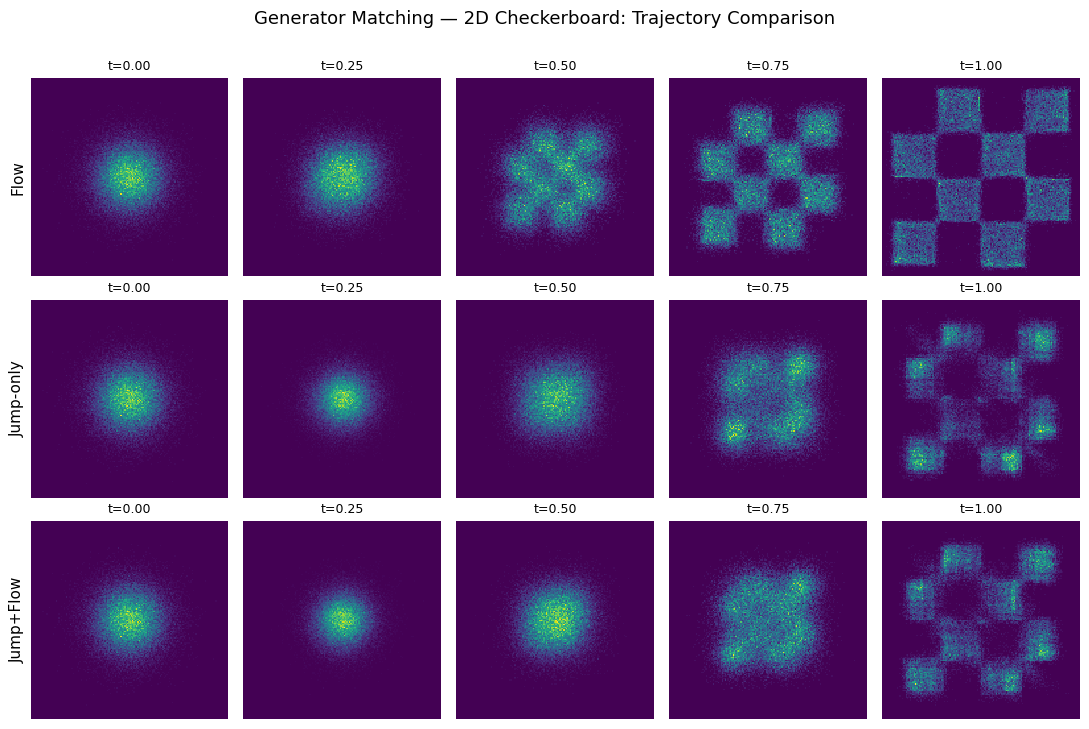

Saved: 2d_trajectory_comparison.png


In [28]:
def plot_row(ax_row, traj, t_vals, title_prefix):
    for j, (ax, t_val) in enumerate(zip(ax_row, t_vals)):
        pts = traj[j].numpy()
        ax.hist2d(pts[:, 0], pts[:, 1], bins=150, range=((-5, 5), (-5, 5)))
        ax.set_aspect('equal')
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(title_prefix, fontsize=11, labelpad=4)
            ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values(): spine.set_visible(False)
        ax.set_title(f't={t_val:.2f}', fontsize=9)


T_labels = torch.linspace(0, 1, N_VIZ).tolist()

fig, axs = plt.subplots(3, N_VIZ, figsize=(N_VIZ * 2.2, 3 * 2.4))
fig.suptitle('Generator Matching — 2D Checkerboard: Trajectory Comparison', fontsize=13, y=1.01)

plot_row(axs[0], sol_flow, T_labels, 'Flow')
plot_row(axs[1], sol_jump, T_labels, 'Jump-only')
plot_row(axs[2], sol_jf,   T_labels, 'Jump+Flow')

plt.tight_layout()
plt.savefig('2d_trajectory_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 2d_trajectory_comparison.png')

## Visualize: Final Samples Comparison (t=1)

Side-by-side comparison of the final generated distributions.

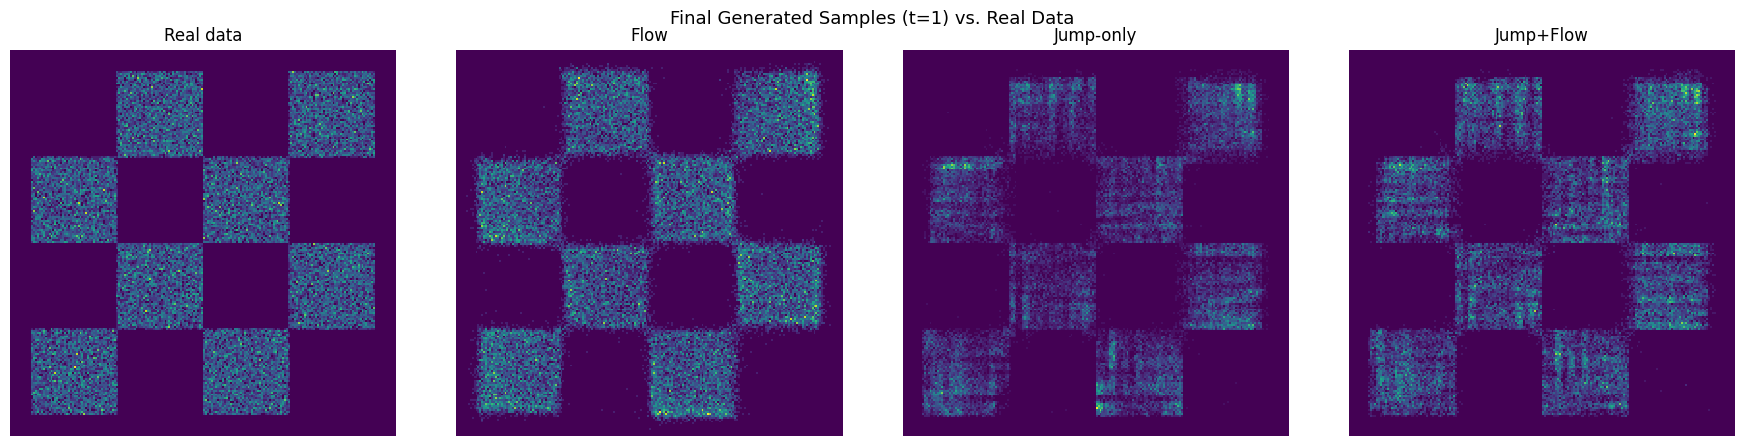

Saved: 2d_final_comparison.png


In [15]:
real_data = inf_train_gen(N_SAMPLES, device='cpu').numpy()

panels = [
    ('Real data',  real_data),
    ('Flow',       sol_flow[-1].numpy()),
    ('Jump-only',  sol_jump[-1].numpy()),
    ('Jump+Flow',  sol_jf[-1].numpy()),
]

fig, axs = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle('Final Generated Samples (t=1) vs. Real Data', fontsize=13)

for ax, (title, pts) in zip(axs, panels):
    ax.hist2d(pts[:, 0], pts[:, 1], bins=200, range=((-5, 5), (-5, 5)))
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.axis('off')

plt.tight_layout()
plt.savefig('2d_final_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 2d_final_comparison.png')

## Visualize: Jump Behavior at Different Times

For the jump models, we can inspect the *fraction of dimensions that jumped* at each Euler step — this shows how active the jump process is over time.

In [16]:
@torch.no_grad()
def measure_jump_rate(model, x_init, bin_centers, step_size=0.01, with_flow=False, alpha=1.0):
    """Return per-step average fraction of dimensions that jump (simple Euler)."""
    device  = x_init.device
    bc      = bin_centers.to(device)
    nb      = bc.shape[0]
    n_steps = round(1.0 / step_size)
    t_grid  = torch.linspace(0.0, 1.0, n_steps + 1).to(device)
    x_t     = x_init.clone()
    jump_fracs = []

    for i in range(n_steps):
        t_val    = t_grid[i].item()
        h        = t_grid[i + 1].item() - t_val
        t_tensor = torch.full((x_t.shape[0],), t_val, device=device)

        if with_flow:
            velocity, jump_logits, log_lambda = model(x_t, t_tensor)
        else:
            jump_logits, log_lambda = model(x_t, t_tensor)

        lambda_t = F.softplus(log_lambda)
        B, D, _  = jump_logits.shape
        J_flat   = torch.softmax(jump_logits, dim=-1).view(B*D, nb)
        bin_idx  = torch.multinomial(J_flat.clamp(min=1e-8), 1).squeeze(-1).view(B, D)
        x_bin    = bc[bin_idx]
        bin_width = (bc[-1] - bc[0]).item() / (nb - 1)
        x_jump   = x_bin + (torch.rand_like(x_bin) - 0.5) * bin_width

        p_jump    = (alpha * h * lambda_t).clamp(max=1.0)
        mask_jump = torch.rand_like(lambda_t) < p_jump
        jump_fracs.append(mask_jump.float().mean().item())

        if with_flow:
            x_flow = x_t + (1.0 - alpha) * h * velocity
            x_t    = torch.where(mask_jump, x_jump, x_flow)
        else:
            x_t    = torch.where(mask_jump, x_jump, x_t)

    return jump_fracs

x_probe = torch.randn(5000, 2, device=device)
t_steps = torch.linspace(0.0, 1.0 - STEP_SIZE, round(1.0 / STEP_SIZE))

fracs_jump = measure_jump_rate(jump_model, x_probe, bin_centers, STEP_SIZE, with_flow=False, alpha=1.0)
fracs_jf   = measure_jump_rate(jf_model,   x_probe, bin_centers, STEP_SIZE, with_flow=True,  alpha=0.5)

fig, ax = plt.subplots(figsize=(8, 3.5))
t_axis  = t_steps.numpy()
ax.plot(t_axis, fracs_jump, "o-", color="tab:red",   label="Jump-only", linewidth=2)
ax.plot(t_axis, fracs_jf,   "s-", color="tab:green", label="Jump+Flow", linewidth=2)
ax.set_xlabel("t"); ax.set_ylabel("Fraction of dims that jump")
ax.set_title("Jump Activity per Euler Step"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("2d_jump_activity.png", dpi=120, bbox_inches="tight")
plt.show()

## Bonus: Effect of Number of Steps on Jump-Only Sampling

Jump models typically need more steps than ODE-based flow models to converge, because they rely on many small jumps.

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

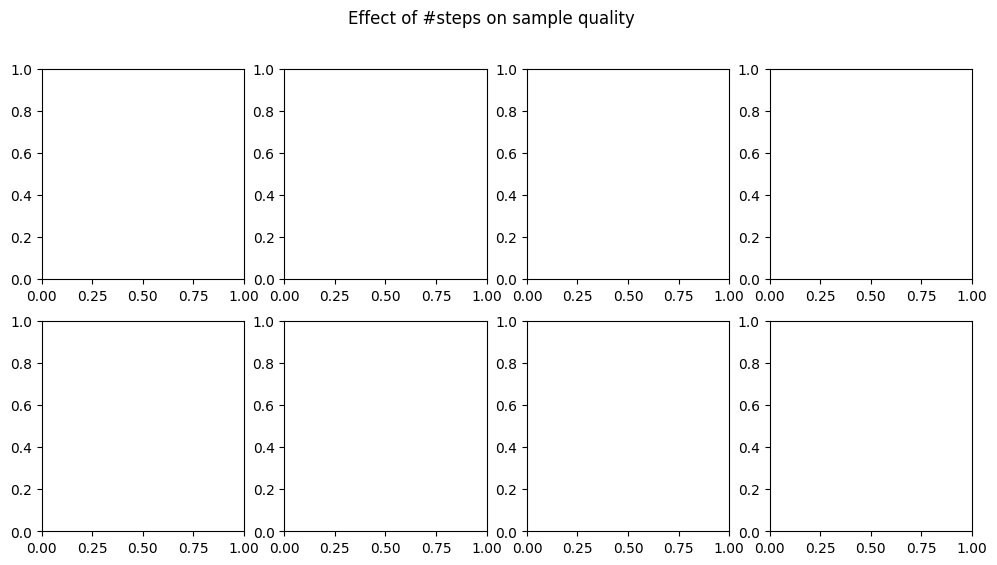

In [17]:
step_sizes = [0.2, 0.1, 0.05, 0.02]
n_steps_list = [round(1 / s) for s in step_sizes]

fig, axs = plt.subplots(3, len(step_sizes), figsize=(len(step_sizes) * 3, 9))
fig.suptitle('Effect of #steps on sample quality', fontsize=12)

for col, (ss, ns) in enumerate(zip(step_sizes, n_steps_list)):
    x_probe2 = torch.randn(30_000, 2, device=device)

    # ── Flow (ODE Euler) ──────────────────────────────────────────────────
    Tg = torch.linspace(0, 1, ns + 1).to(device)
    sf = ode_solver.sample(
        time_grid=Tg, x_init=x_probe2,
        method='euler', step_size=ss,
        return_intermediates=False,
    ).cpu().numpy()
    axs[0, col].hist2d(sf[:, 0], sf[:, 1], bins=100, range=((-5,5),(-5,5)))
    axs[0, col].set_title(f'{ns} steps', fontsize=10)
    axs[0, col].set_aspect('equal'); axs[0, col].axis('off')
    if col == 0:
        axs[0, col].set_ylabel('Flow', fontsize=10)
        axs[0, col].axis('on'); axs[0, col].set_xticks([]); axs[0, col].set_yticks([])
        for sp in axs[0, col].spines.values(): sp.set_visible(False)

    # ── Jump-only ─────────────────────────────────────────────────────────
    sj = sample_jump_2d(jump_model, x_probe2, bin_centers,
                         step_size=ss, with_flow=False).cpu().numpy()
    axs[1, col].hist2d(sj[:, 0], sj[:, 1], bins=100, range=((-5,5),(-5,5)))
    axs[1, col].set_aspect('equal'); axs[1, col].axis('off')
    if col == 0:
        axs[1, col].set_ylabel('Jump-only', fontsize=10)
        axs[1, col].axis('on'); axs[1, col].set_xticks([]); axs[1, col].set_yticks([])
        for sp in axs[1, col].spines.values(): sp.set_visible(False)

    # ── Jump+Flow ─────────────────────────────────────────────────────────
    sjf = sample_jump_2d(jf_model, x_probe2, bin_centers,
                          step_size=ss, with_flow=True).cpu().numpy()
    axs[2, col].hist2d(sjf[:, 0], sjf[:, 1], bins=100, range=((-5,5),(-5,5)))
    axs[2, col].set_aspect('equal'); axs[2, col].axis('off')
    if col == 0:
        axs[2, col].set_ylabel('Jump+Flow', fontsize=10)
        axs[2, col].axis('on'); axs[2, col].set_xticks([]); axs[2, col].set_yticks([])
        for sp in axs[2, col].spines.values(): sp.set_visible(False)

plt.tight_layout()
plt.savefig('2d_step_ablation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 2d_step_ablation.png')


## Animation: Smooth Trajectory GIF

In [33]:
import matplotlib.animation as animation
from IPython.display import Image, display

# Re-sample using same STEP_SIZE as main sampling (NFE stays consistent)
N_ANIM  = round(1.0 / STEP_SIZE)
ANIM_SS = STEP_SIZE

x_anim = torch.randn(N_SAMPLES, 2, device=device)

T_anim_grid = torch.linspace(0, 1, N_ANIM + 1).to(device)
sol_flow_anim = ode_solver.sample(
    time_grid=T_anim_grid, x_init=x_anim,
    method="midpoint", step_size=ANIM_SS,
    return_intermediates=True
).cpu()

sol_jump_anim = sample_jump_2d(
    jump_model, x_anim, bin_centers,
    step_size=ANIM_SS, with_flow=False, alpha=1.0,
    return_intermediates=True
)
sol_jf_anim = sample_jump_2d(
    jf_model, x_anim, bin_centers,
    step_size=ANIM_SS, with_flow=True, alpha=0.5,
    return_intermediates=True
)

print(f"NFE={N_ANIM}, shapes: {sol_flow_anim.shape}, {sol_jump_anim.shape}, {sol_jf_anim.shape}")


In [34]:
trajs  = [sol_flow_anim, sol_jump_anim, sol_jf_anim]
titles = ['Flow', 'Jump-only', 'Jump+Flow']

fig, axs = plt.subplots(1, 3, figsize=(13, 4.5))
fig.patch.set_facecolor('black')
for ax in axs:
    ax.set_facecolor('black')
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect('equal'); ax.axis('off')

time_label = fig.text(0.5, 0.97, 't = 0.00', ha='center', va='top',
                      fontsize=14, color='white')

def draw_frame(frame):
    t_val = frame / N_ANIM
    time_label.set_text(f't = {t_val:.2f}')
    artists = []
    for ax, title, traj in zip(axs, titles, trajs):
        ax.cla()
        ax.set_facecolor('black')
        ax.set_aspect('equal'); ax.axis('off')
        ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
        pts = traj[frame].numpy()
        ax.hist2d(pts[:, 0], pts[:, 1], bins=120,
                  range=((-5, 5), (-5, 5)))
        ax.set_title(title, fontsize=12, color='white', pad=4)
    return []

plt.tight_layout(rect=[0, 0, 1, 0.95])

anim = animation.FuncAnimation(
    fig, draw_frame,
    frames=N_ANIM + 1,
    interval=50,      # ms between frames → 20 fps
    blit=False,
)

gif_path = '2d_animation.gif'
anim.save(gif_path, writer='pillow', fps=20, dpi=100)
plt.close()
print(f'Saved: {gif_path}')

# Read bytes each time to avoid Jupyter cache
with open(gif_path, "rb") as _f:
    display(Image(data=_f.read(), format="gif"))

## Individual Particle Trajectories (paper Figure 2 style)

In [31]:
@torch.no_grad()
def sample_traj_with_jump_mask(model, x_init, bin_centers,
                                step_size=0.01, with_flow=False, alpha=1.0):
    """Like sample_jump_2d but also returns a boolean mask of when jumps occurred."""
    device    = x_init.device
    bc        = bin_centers.to(device)
    nb        = bc.shape[0]
    bin_width = (bc[-1] - bc[0]).item() / (nb - 1)

    n_steps = round(1.0 / step_size)
    t_grid  = torch.linspace(0.0, 1.0, n_steps + 1).to(device)

    x_t    = x_init.clone()
    traj   = [x_t.cpu()]
    jumped = []

    for i in range(n_steps):
        t_val    = t_grid[i].item()
        h        = t_grid[i + 1].item() - t_val
        t_tensor = torch.full((x_t.shape[0],), t_val, device=device)

        if with_flow:
            velocity, jump_logits, log_lambda = model(x_t, t_tensor)
        else:
            jump_logits, log_lambda = model(x_t, t_tensor)

        lambda_t  = F.softplus(log_lambda)
        B, D, _   = jump_logits.shape
        J_flat    = torch.softmax(jump_logits, dim=-1).view(B * D, nb)
        bin_idx   = torch.multinomial(J_flat.clamp(min=1e-8), 1).squeeze(-1).view(B, D)
        x_bin     = bc[bin_idx]
        x_jump    = x_bin + (torch.rand_like(x_bin) - 0.5) * bin_width

        # Simple Euler: P[jump] = alpha * h * lambda_t
        p_jump    = (alpha * h * lambda_t).clamp(max=1.0)
        mask_jump = torch.rand_like(lambda_t) < p_jump

        jumped.append(mask_jump.any(dim=-1).cpu())

        if with_flow:
            x_flow = x_t + (1.0 - alpha) * h * velocity
            x_t    = torch.where(mask_jump, x_jump, x_flow)
        else:
            x_t    = torch.where(mask_jump, x_jump, x_t)

        traj.append(x_t.cpu())

    return torch.stack(traj, dim=0), torch.stack(jumped, dim=0)

In [32]:
from matplotlib.lines import Line2D

# 3 fixed starting points (same for all models)
N_TRAJ   = 3
TRAJ_SS  = STEP_SIZE   # same NFE as main sampling
torch.manual_seed(0)
x0_traj  = torch.randn(N_TRAJ, 2, device=device)

# Flow trajectory
T_traj = torch.linspace(0, 1, round(1 / TRAJ_SS) + 1).to(device)
flow_traj = ode_solver.sample(
    time_grid=T_traj, x_init=x0_traj,
    method="midpoint", step_size=TRAJ_SS,
    return_intermediates=True
).cpu()

# Jump-only trajectory
jump_traj, jump_mask = sample_traj_with_jump_mask(
    jump_model, x0_traj, bin_centers,
    step_size=TRAJ_SS, with_flow=False, alpha=1.0)

# Jump+Flow trajectory
jf_traj, jf_mask = sample_traj_with_jump_mask(
    jf_model, x0_traj, bin_centers,
    step_size=TRAJ_SS, with_flow=True, alpha=0.5)

# Plot
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_facecolor("white")
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_aspect("equal"); ax.axis("off")

COLORS = {"flow": "tab:red", "jump": "tab:blue", "ms": "tab:green"}
ALPHA  = 0.85

for p in range(N_TRAJ):
    fx = flow_traj[:, p, 0].numpy(); fy = flow_traj[:, p, 1].numpy()
    ax.plot(fx, fy, color=COLORS["flow"], lw=1.8, alpha=ALPHA, zorder=2)

    jx = jump_traj[:, p, 0].numpy(); jy = jump_traj[:, p, 1].numpy()
    ax.plot(jx, jy, color=COLORS["jump"], lw=1.5, ls="--", alpha=ALPHA, zorder=2)
    j_steps = jump_mask[:, p].numpy()
    ax.scatter(jx[1:][j_steps], jy[1:][j_steps],
               marker="x", c="black", s=70, lw=1.5, zorder=5)

    mx = jf_traj[:, p, 0].numpy(); my = jf_traj[:, p, 1].numpy()
    ax.plot(mx, my, color=COLORS["ms"], lw=1.8, alpha=ALPHA, zorder=2)
    m_steps = jf_mask[:, p].numpy()
    ax.scatter(mx[1:][m_steps], my[1:][m_steps],
               marker="x", c="black", s=70, lw=1.5, zorder=5)

legend_elems = [
    Line2D([0],[0], color=COLORS["flow"],  lw=2,         label="Flow"),
    Line2D([0],[0], color=COLORS["jump"],  lw=2, ls="--", label="Jump"),
    Line2D([0],[0], color=COLORS["ms"],    lw=2,         label="MS (Jump+Flow)"),
    Line2D([0],[0], marker="x", color="black", ls="none", markersize=9,
           lw=1.5, label="Jump point"),
]
ax.legend(handles=legend_elems, fontsize=11, loc="lower right",
          framealpha=0.9, edgecolor="gray")

plt.tight_layout()
plt.savefig("2d_particle_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved (NFE={round(1/TRAJ_SS)}): 2d_particle_trajectories.png")
